# Create WecOptTool Model for the Marson WEC concept

In [5]:
import logging
import numpy as np
import capytaine as cpt
import pygmsh
import gmsh
import vtk
import matplotlib.pyplot as plt
import os
import xarray as xr
from capytaine.io.meshio import load_from_meshio
from capytaine.io.legacy import export_hydrostatics

logging.basicConfig(level=logging.INFO,format="%(levelnames)s:\t%(message)s")

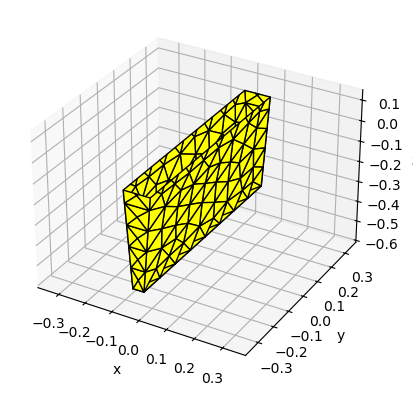

In [6]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop = 0.1
flapWidth = 0.76
flapHeight = 0.5
flapCG = [0, 0, -0.36] # from water surface/origin

with pygmsh.geo.Geometry() as geom:
    flap = geom.add_polygon(
            [[-flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessBottom/2, -flapWidth/2, -0.46],
            [flapThicknessTop/2, -flapWidth/2, -0.46+flapHeight],
            [-flapThicknessTop/2, -flapWidth/2, -0.46+flapHeight]],mesh_size=0.1)
    geom.extrude(flap,[0,flapWidth,0])
    flapMesh = geom.generate_mesh()

# define the floating body
flap = cpt.FloatingBody(mesh=flapMesh, name=f'flap', center_of_mass=flapCG)
flap.rotation_center = flapCG # define rotation about cg and M4E will handle transformaiton
flap.add_all_rigid_body_dofs()
flap = flap.immersed_part()
flap.inertia_matrix = flap.compute_rigid_body_inertia()
flap.hydrostatic_stiffness = flap.immersed_part().compute_hydrostatic_stiffness(rho=1025)
#rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([0.5*(.05*.76*.56)*1000,0.5*(.05*.76*.56)*1000,1.19]))),
#                            dims=['influenced_dof', 'radiating_dof'],
#                            coords={'influenced_dof': list(flap.dofs),
#                                    'radiating_dof': list(flap.dofs)},
#                            name="inertia_matrix")

# Set FloatingBody inertia matrix
#flap.inertia_matrix = rigid_inertia_matrix_xr
#flap.hydrostatic_stiffness = flap.compute_hydrostatic_stiffness(rho=1025)

flap.show_matplotlib()
#flap.show()

#### WEC geometry mesh
Now we will create a surface mesh for the WEC hull and store it using the `FloatingBody` object from Capytaine.

In [7]:
ncFName = 'flap.nc'

path,tmp = os.path.split(os.getcwd() + os.path.sep + ncFName)
path += os.path.sep

# combine all bodies to account for B2B interaction

#both_fb = cpt.FloatingBody.join_bodies(rect1,rect2)

freqs = np.linspace(1/8, 10*1/8, 10)

# set frequencies
wCapy =  2*np.pi*freqs                  # wave frequencies
headings = np.linspace(0,np.pi/2,1)  
depth = np.inf
density = 1025.0

# call Capytaine solver
print(f'\n-------------------------------\n'
    f'Calling Capytaine BEM solver...\n'
    f'-------------------------------\n'
    f'mesh = {flap.name}\n'
    f'w range = {wCapy[0]:.3f} - {wCapy[-1]:.3f} rad/s\n'
    f'dw = {(wCapy[1]-wCapy[0]):.3f} rad/s\n'
    f'no of headings = {len(headings)}\n'
    f'no of radiation & diffraction problems = {len(wCapy)*(len(headings) + len(flap.dofs))}\n'
    f'-------------------------------\n')

problems = xr.Dataset(coords={
    'omega': wCapy,
    'wave_direction': headings,
    'radiating_dof': list(flap.dofs),
    'water_depth': [depth],
    'rho': [density],
    })

solver = cpt.BEMSolver()
capyData = solver.fill_dataset(problems, [flap], hydrostatics=True)

#capyData = cpt.io.xarray.separate_complex_values(capyData)
# save to .nc file
#capyData.to_netcdf(ncFName, encoding={'radiating_dof': {'dtype': 'U'}, 'influenced_dof': {'dtype': 'U'}})


cpt.export_dataset(os.path.join('', 'flap.nc'), capyData)
export_hydrostatics('hs', flap)

Output()


-------------------------------
Calling Capytaine BEM solver...
-------------------------------
mesh = flap
w range = 0.785 - 7.854 rad/s
dw = 0.785 rad/s
no of headings = 1
no of radiation & diffraction problems = 70
-------------------------------



[14:14:07] WARNING  Exporting problem in already existing directory: hs                                            
                                 You might be overwriting existing files!